In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
simuls = pd.read_csv("simul.csv")
data_long = simuls.melt(
    id_vars=[c for c in simuls.columns if not c.startswith("Precision_quantile_")],
    value_vars=[c for c in simuls.columns if c.startswith("Precision_quantile_")],
    var_name="combined",
    value_name="Precision"
)

data_long[["Metric", "Quantile"]] = data_long["combined"].str.extract(r"(.*)_quantile_(.*)")
data_long["Quantile"] = data_long["Quantile"].astype(float).round(4)
data_long = data_long.drop(columns="combined")

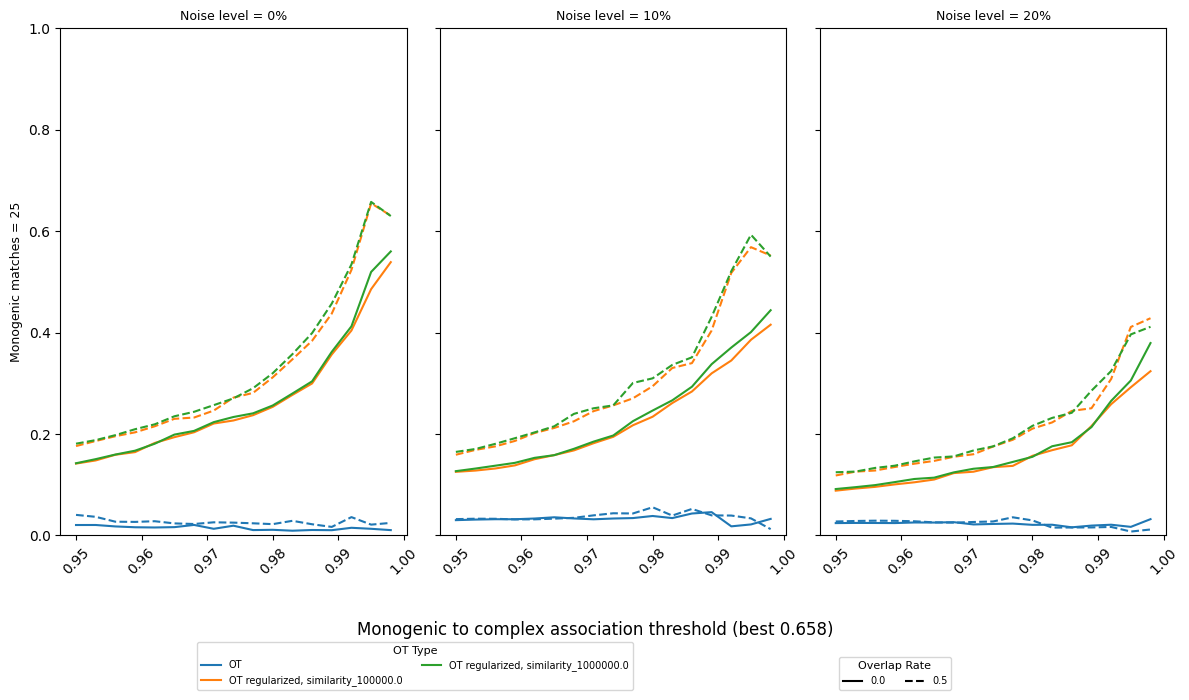

In [7]:
# Valeurs uniques pour la grille
n_matches = sorted(data_long["n_match"].unique())
noise_levels = sorted(data_long["noise_level"].unique())

# Plot
fig, axes = plt.subplots(
    len(n_matches), len(noise_levels),
    figsize=(12, 7),
    sharex=True, sharey=True
)

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
#ot_types = sorted(data_long["OT_type"].unique())
ot_types = ['OT', 'OT regularized, similarity']
overlap_rates = sorted(data_long["overlap_rate"].unique())
etas = sorted(data_long["eta"].unique())
linestyles = ["-", "--", "-.", ":"]

color_map = {}
idx = 0
for ot in ot_types:
    if ot == 'OT':
        color_map[(ot, None)] = colors[idx % len(colors)]
        idx += 1
    else:
        for eta in etas:
            if eta != 0.0:
                color_map[(ot, eta)] = colors[idx % len(colors)]
                idx += 1

for i, n_match in enumerate(n_matches):
    for j, noise in enumerate(noise_levels):
        if len(n_matches)==1 and len(noise_levels)==1:
            ax = axes
        elif len(n_matches) == 1:
            ax = axes[j]
        elif len(noise_levels) == 1:
            ax = axes[i]
        else:
            ax = axes[i, j]
        subset = data_long[(data_long["n_match"] == n_match) & (data_long["noise_level"] == noise)]

        for k, ot in enumerate(ot_types):
            for l, rate in enumerate(overlap_rates):
                if ot == 'OT':
                    sub = subset[(subset["OT_type"] == ot) & (subset["overlap_rate"] == rate) & (subset["eta"] == 0.0)]
                    ax.plot(
                        sub["Quantile"], sub["Precision"],
                        color=color_map[(ot, None)],
                        linestyle=linestyles[l % len(linestyles)],
                        # linewidth=10,
                        zorder=10,
                        label=f"{ot} / {rate}"
                    )
                else : 
                    for e, eta in enumerate(etas):
                        if eta != 0.0 :
                            sub = subset[(subset["OT_type"] == ot) & (subset["overlap_rate"] == rate) & (subset["eta"] == eta)]
                            ax.plot(
                                sub["Quantile"], sub["Precision"],
                                color=color_map[(ot, eta)],
                                linestyle=linestyles[l % len(linestyles)],
                                label=f"{ot} / {rate}/ {eta}" if i == 0 and j == 0 else ""
                            )

        ax.set_ylim(0, 1)
        ax.tick_params(axis="x", rotation=45)

        if i == 0:
            ax.set_title(f"Noise level = {noise * 100:.0f}%", fontsize=9)
        if j == 0:
            ax.set_ylabel(f"Monogenic matches = {n_match}", fontsize=9)

# Légendes séparées pour OT_type et overlap_rate
ot_handles = []
for k, ot in enumerate(ot_types):
    if ot == 'OT':
        ot_handles.append(plt.Line2D([0], [0], color=color_map[(ot, None)], label=f"{str(ot)}"))
    else :
        for e, eta in enumerate(etas):
            if eta != 0.0:
                ot_handles.append(plt.Line2D([0], [0], color=color_map[(ot, eta)], label=f"{str(ot)}_{eta}"))
rate_handles = [plt.Line2D([0], [0], color="black", linestyle=linestyles[l % len(linestyles)], label=str(r)) for l, r in enumerate(overlap_rates)]

fig.legend(handles=ot_handles, loc="lower center", ncol=len(ot_types), bbox_to_anchor=(0.35, 0), fontsize=7, title="OT Type", title_fontsize=8)
fig.legend(handles=rate_handles, loc="lower center", ncol=len(overlap_rates), bbox_to_anchor=(0.75, 0), fontsize=7, title="Overlap Rate", title_fontsize=8)

fig.supxlabel(f"Monogenic to complex association threshold (best {np.round(data_long["Precision"].max(), 3)})", y=0.08)
plt.tight_layout(rect=[0, 0.1, 1, 1])

plt.show()